1. Import Libraries

In [47]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


2. Load Dataset

In [48]:
# Load the dataset into a DataFrame
df = pd.read_csv("ai_jobs_market_2025_2026 (1).csv")

# Show the first 5 rows
df.head()

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


3. Dataset Shape

In [49]:
# Check number of rows and columns
df.shape

(1500, 25)

In [50]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1500
Number of columns: 25


4. Column Names

In [51]:
# Display all column names
df.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier'],
      dtype='object')

5. Dataset Info

In [52]:
# Show data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_id                 1500 non-null   object 
 1   job_title              1500 non-null   object 
 2   job_category           1500 non-null   object 
 3   experience_level       1500 non-null   object 
 4   years_of_experience    1500 non-null   int64  
 5   education_required     1500 non-null   object 
 6   annual_salary_usd      1500 non-null   float64
 7   salary_min_usd         1500 non-null   int64  
 8   salary_max_usd         1500 non-null   int64  
 9   city                   1500 non-null   object 
 10  country                1500 non-null   object 
 11  remote_work            1500 non-null   object 
 12  company_size           1500 non-null   object 
 13  industry               1500 non-null   object 
 14  required_skills        1500 non-null   object 
 15  ai_s

6. Missing Values

In [53]:
# Check missing values in each column
df.isnull().sum()

job_id                   0
job_title                0
job_category             0
experience_level         0
years_of_experience      0
education_required       0
annual_salary_usd        0
salary_min_usd           0
salary_max_usd           0
city                     0
country                  0
remote_work              0
company_size             0
industry                 0
required_skills          0
ai_salary_premium_pct    0
demand_score             0
demand_growth_yoy_pct    0
benefits_score_10        0
posting_year             0
posting_month            0
is_senior                0
is_remote_friendly       0
is_llm_role              0
salary_tier              0
dtype: int64

No missing values

7. Duplicates

In [54]:
df.duplicated().sum()

np.int64(0)

No duplicates

*8*. Top 10 AI Job Titles

In [55]:
# Count the top 10 most common job titles
top_jobs = df["job_title"].value_counts().head(10)

top_jobs

job_title
LLM Engineer              75
Robotics Engineer (AI)    74
Prompt Engineer           71
Generative AI Engineer    71
AI Product Manager        70
Multimodal AI Engineer    67
Senior Data Scientist     66
AI Compliance Manager     66
Senior ML Engineer        64
AI Engineer               64
Name: count, dtype: int64

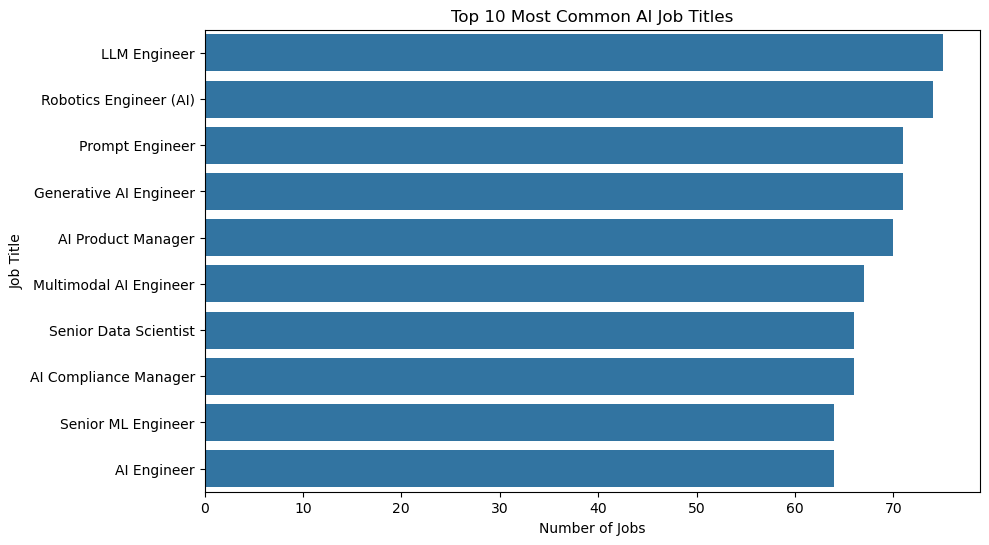

In [56]:
# Plot top 10 job titles
plt.figure(figsize=(10, 6))
sns.barplot(x=top_jobs.values, y=top_jobs.index)

plt.title("Top 10 Most Common AI Job Titles")
plt.xlabel("Number of Jobs")
plt.ylabel("Job Title")

plt.show()

9. Salary Distribution12.

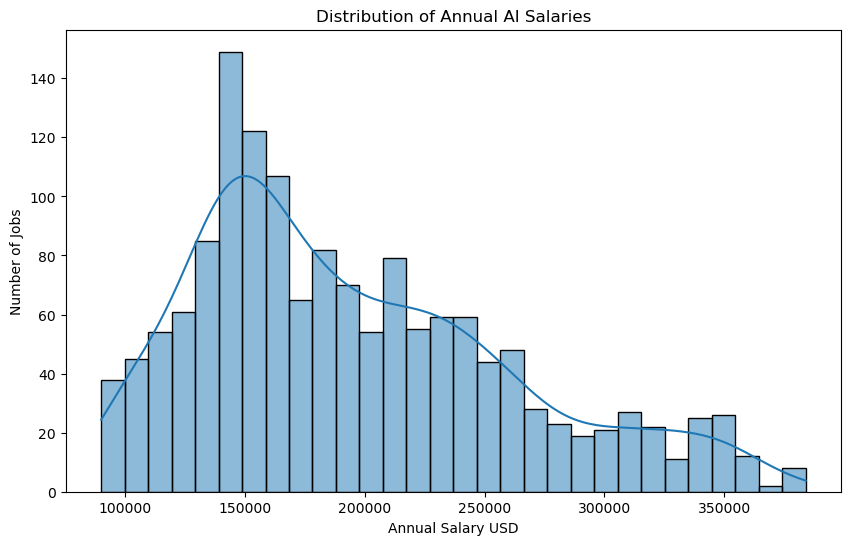

In [57]:
# Plot salary distribution
plt.figure(figsize=(10, 6))
sns.histplot(df["annual_salary_usd"], bins=30, kde=True)

plt.title("Distribution of Annual AI Salaries")
plt.xlabel("Annual Salary USD")
plt.ylabel("Number of Jobs")

plt.show()

10. Salary by Experience Level

In [58]:
# Salary summary by experience level
salary_by_experience = df.groupby("experience_level")["annual_salary_usd"].agg(
    count="count",
    mean="mean",
    median="median",
    min="min",
    max="max"
).sort_values(by="mean", ascending=False)

salary_by_experience

,count,mean,median,min,max
experience_level,,,,,
Lead (10+ yrs),381,240055.118110,238000.0,90000.0,384000.0
Senior (6-9 yrs),364,214280.219780,208000.0,95000.0,374400.0
Mid (3-5 yrs),370,175983.783784,162000.0,94000.0,354000.0
Entry (0-2 yrs),385,150038.961039,145000.0,90000.0,300000.0


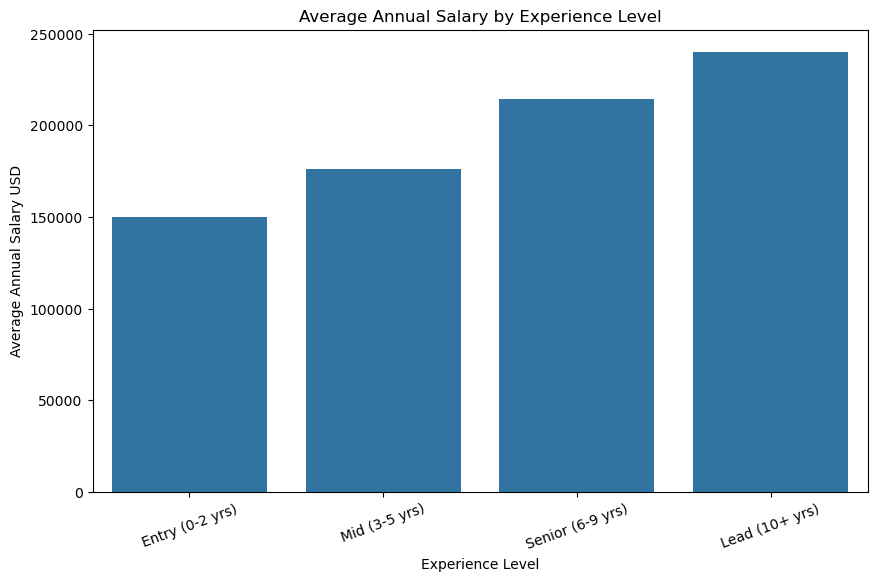

In [59]:
# Average salary by experience level
experience_salary_mean = df.groupby("experience_level")["annual_salary_usd"].mean().sort_values()

plt.figure(figsize=(10, 6))
sns.barplot(x=experience_salary_mean.index, y=experience_salary_mean.values)

plt.title("Average Annual Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Annual Salary USD")
plt.xticks(rotation=20)

plt.show()

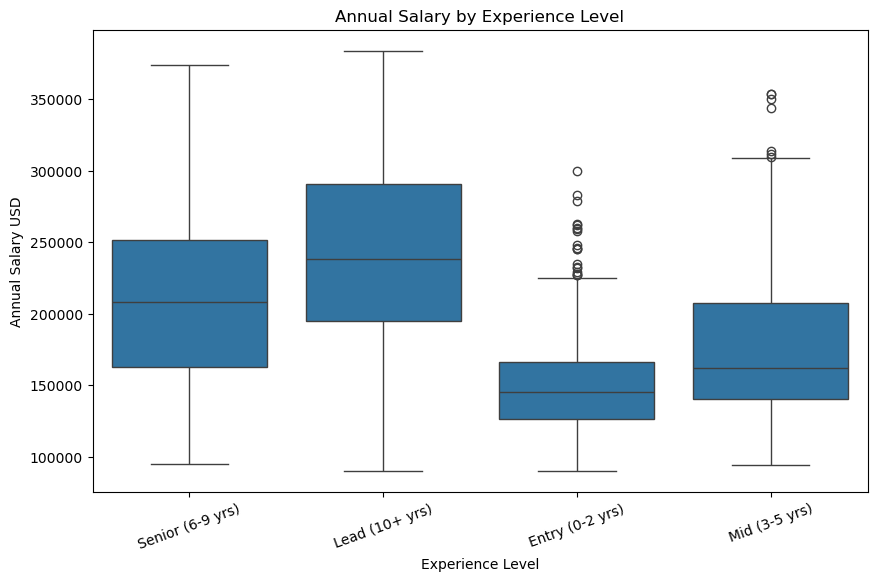

In [60]:
# Boxplot: salary by experience level
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="experience_level", y="annual_salary_usd")

plt.title("Annual Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Annual Salary USD")
plt.xticks(rotation=20)

plt.show()

11. Top Countries by Average Salary

In [61]:
# Average salary by country
country_salary = (
    df.groupby("country")["annual_salary_usd"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

country_salary

country
USA            226189.902913
Global         222043.902439
UAE            194225.806452
Switzerland    190592.105263
Australia      188000.000000
France         183151.515152
Singapore      181830.985915
Germany        181180.246914
UK             180644.444444
Canada         180588.235294
Name: annual_salary_usd, dtype: float64

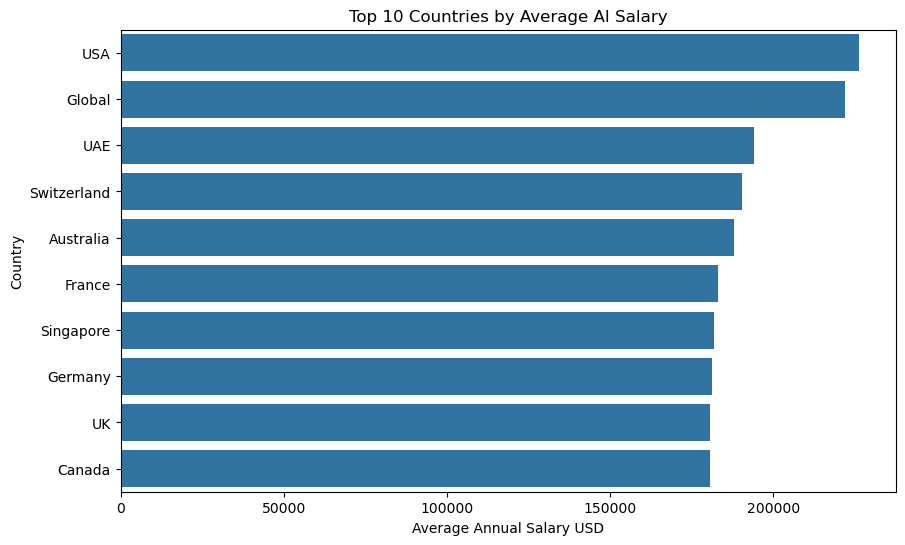

In [62]:
# Plot top 10 countries by average salary
plt.figure(figsize=(10, 6))
sns.barplot(x=country_salary.values, y=country_salary.index)

plt.title("Top 10 Countries by Average AI Salary")
plt.xlabel("Average Annual Salary USD")
plt.ylabel("Country")

plt.show()

12.Salary Range

In [63]:
# Create a new feature: salary range
df["salary_range_usd"] = df["salary_max_usd"] - df["salary_min_usd"]

# Display the new column with salary columns
df[["salary_min_usd", "salary_max_usd", "salary_range_usd"]].head()

,salary_min_usd,salary_max_usd,salary_range_usd
0,155000,290000,135000
1,90000,200000,110000
2,160000,300000,140000
3,130000,220000,90000
4,140000,260000,120000


A new feature called `salary_range_usd` was created by subtracting the minimum salary from the maximum salary. This feature helps show how wide the salary range is for each AI job posting.

## Final Insights

The EDA shows that the AI jobs market contains different job titles, categories, experience levels, countries, company sizes, and salary tiers. The average annual salary is high, but salaries vary based on multiple factors. Job title, country, company size, remote work type, and required skills may all affect salary differences.

The analysis also shows that years of experience alone does not strongly explain salary differences, so salary should be analyzed with other factors such as job category, country, and company size. Overall, this dataset provides useful insights into AI job market trends for 2025–2026.

In [64]:
df.columns

Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier', 'salary_range_usd'],
      dtype='object')